This notebook evaluates the fine-tuned NLLB-200 model using standard MT metrics 
— BLEU, chrF++, and TER — on a 100-pair held-out test set, comparing performance 
against the zero-shot baseline across seven medical domains.


## Install Packages

In [1]:
import subprocess, sys

for pkg in ['pandas', 'matplotlib', 'seaborn', 'sacrebleu', 'sentencepiece', 'torch', 'transformers']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print(' All packages installed.')


 All packages installed.


## Imports & Paths

In [2]:
import os, warnings, torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sacrebleu
from transformers import AutoModelForSeq2SeqLM, NllbTokenizerFast

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

ROOT        = os.path.abspath(os.path.join(os.getcwd(), '..'))
CORPUS_PATH = os.path.join(ROOT, 'backend', 'data', 'medical_corpus.csv')
EVAL_PATH   = os.path.join(ROOT, 'backend', 'data', 'evaluation_examples.csv')
CHECKPOINT  = os.path.join(ROOT, 'checkpoints', 'best_model')

print(f'Corpus     : {CORPUS_PATH}')
print(f'Eval set   : {EVAL_PATH}')
print(f'Checkpoint : {CHECKPOINT}')


c:\sesotho-medical-mt\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Corpus     : c:\sesotho-medical-mt\backend\data\medical_corpus.csv
Eval set   : c:\sesotho-medical-mt\backend\data\evaluation_examples.csv
Checkpoint : c:\sesotho-medical-mt\checkpoints\best_model


## Load Corpus

In [3]:
corpus = pd.read_csv(CORPUS_PATH)

print(f'Total pairs : {len(corpus):,}')
print(f'Columns     : {list(corpus.columns)}')
print(f'\nMissing values:\n{corpus.isnull().sum().to_string()}')


Total pairs : 5,000
Columns     : ['sentence_id', 'domain_category', 'english_text', 'sesotho_text', 'source', 'source_reference', 'translator_code', 'reviewer_status', 'notes']

Missing values:
sentence_id            0
domain_category        0
english_text           0
sesotho_text           0
source                 0
source_reference       0
translator_code     5000
reviewer_status        0
notes               5000


## Domain Distribution Table

In [4]:
domain_counts = corpus['domain_category'].value_counts().reset_index()
domain_counts.columns = ['Domain', 'Count']
domain_counts['Percentage (%)'] = (domain_counts['Count'] / len(corpus) * 100).round(1)

print(f'Domains covered: {len(domain_counts)}\n')
print(domain_counts.to_string(index=False))


Domains covered: 7

                    Domain  Count  Percentage (%)
                       HIV   1000            20.0
   Medication Instructions    900            18.0
              Tuberculosis    800            16.0
   Symptoms and Complaints    800            16.0
 General Patient Education    600            12.0
Appointments and Follow-Up    500            10.0
 Maternal and Child Health    400             8.0


## Domain Bar Chart

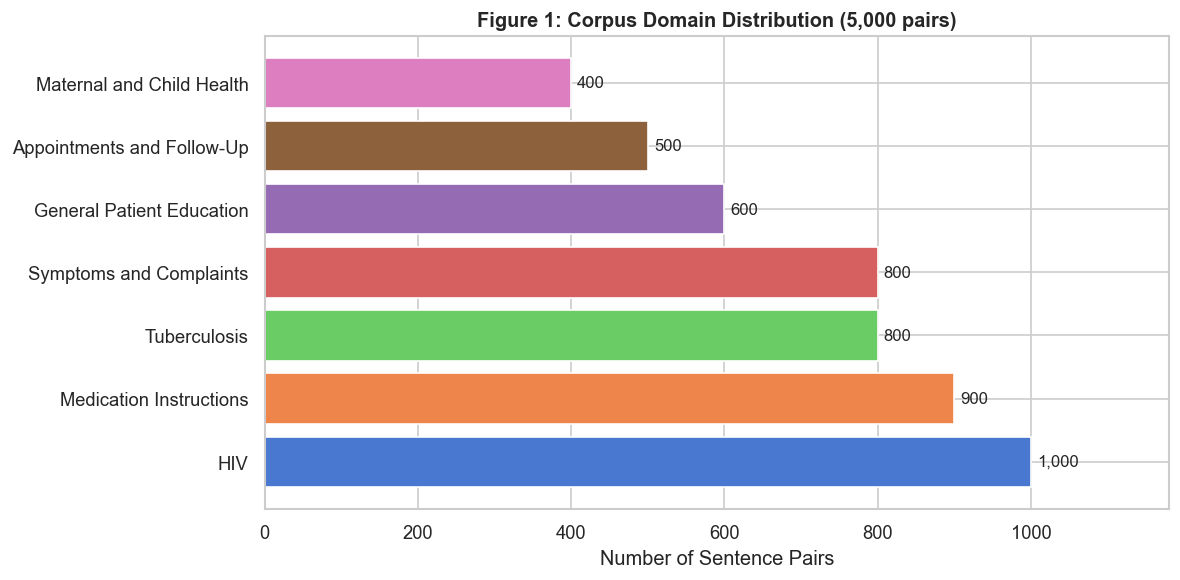

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    domain_counts['Domain'],
    domain_counts['Count'],
    color=sns.color_palette('muted', len(domain_counts)),
    edgecolor='white'
)

for bar, count in zip(bars, domain_counts['Count']):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', fontsize=10)

ax.set_xlabel('Number of Sentence Pairs')
ax.set_xlim(0, domain_counts['Count'].max() * 1.18)
ax.set_title(f'Figure 1: Corpus Domain Distribution ({len(corpus):,} pairs)', fontweight='bold')

plt.tight_layout()
plt.savefig('figure1_domain_distribution.png', bbox_inches='tight')
plt.show()


## Figure 2: Reviewer Status Pie Chart

  Status  Count  Percentage (%)
reviewed   4536            90.7
     raw    459             9.2
verified      5             0.1


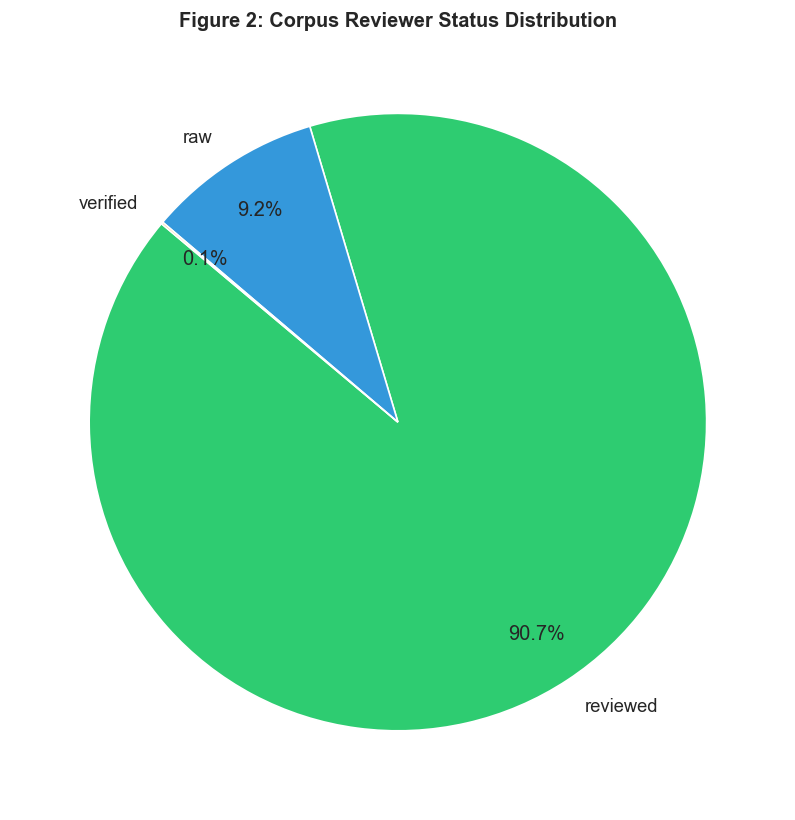

In [6]:
status_counts = corpus['reviewer_status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']
status_counts['Percentage (%)'] = (status_counts['Count'] / len(corpus) * 100).round(1)
print(status_counts.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    status_counts['Count'],
    labels=status_counts['Status'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6'][:len(status_counts)],
    startangle=140,
    pctdistance=0.82
)
ax.set_title('Figure 2: Corpus Reviewer Status Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('figure2_reviewer_status.png', bbox_inches='tight')
plt.show()


## Model Summary Table

In [7]:
model_summary = pd.DataFrame({
    'Property': [
        'Model name',
        'HuggingFace ID',
        'Architecture',
        'Parameters',
        'Languages',
        'Sesotho token',
        'English token',
        'Training mode',
        'Fine-tuning corpus',
        'Fine-tuning epochs',
        'Final val loss',
        'Domain adaptation',
        'Framework',
        'Disk size',
    ],
    'Value': [
        'NLLB-200 Distilled',
        'facebook/nllb-200-distilled-600M',
        'Transformer Encoder–Decoder (Seq2Seq)',
        '~600 million',
        '200 languages',
        'sot_Latn',
        'eng_Latn',
        'Fine-tuned (supervised)',
        '137,418 English–Sesotho medical pairs',
        '3  (val loss: 1.8005 → 1.7153 → 1.6941)',
        '1.6941 (epoch 3 best checkpoint)',
        'Retrieval cache + fine-tuned model fallback',
        'HuggingFace Transformers + PyTorch',
        '~2.5 GB',
    ]
})

print(model_summary.to_string(index=False))


          Property                                       Value
        Model name                          NLLB-200 Distilled
    HuggingFace ID            facebook/nllb-200-distilled-600M
      Architecture       Transformer Encoder–Decoder (Seq2Seq)
        Parameters                                ~600 million
         Languages                               200 languages
     Sesotho token                                    sot_Latn
     English token                                    eng_Latn
     Training mode                     Fine-tuned (supervised)
Fine-tuning corpus       137,418 English–Sesotho medical pairs
Fine-tuning epochs     3  (val loss: 1.8005 → 1.7153 → 1.6941)
    Final val loss            1.6941 (epoch 3 best checkpoint)
 Domain adaptation Retrieval cache + fine-tuned model fallback
         Framework          HuggingFace Transformers + PyTorch
         Disk size                                     ~2.5 GB


## Model Selection Comparison Table

In [8]:
model_comparison = pd.DataFrame([
    {'Model': 'NLLB-200 (600M)',  'Sesotho': 'Yes (sot_Latn)', 'Open': 'Yes', 'Decision': 'SELECTED — fine-tuned'},
    {'Model': 'mBART-50',         'Sesotho': 'Limited',         'Open': 'Yes', 'Decision': 'Comparison only'},
    {'Model': 'Google Translate', 'Sesotho': 'Yes',             'Open': 'No',  'Decision': 'Rejected — closed source'},
    {'Model': 'Microsoft Azure',  'Sesotho': 'Partial',         'Open': 'No',  'Decision': 'Rejected — proprietary API'},
    {'Model': 'Opus-MT',          'Sesotho': 'Limited',         'Open': 'Yes', 'Decision': 'Rejected — no Sesotho medical model'},
])

print(model_comparison.to_string(index=False))


           Model        Sesotho Open                            Decision
 NLLB-200 (600M) Yes (sot_Latn)  Yes               SELECTED — fine-tuned
        mBART-50        Limited  Yes                     Comparison only
Google Translate            Yes   No            Rejected — closed source
 Microsoft Azure        Partial   No          Rejected — proprietary API
         Opus-MT        Limited  Yes Rejected — no Sesotho medical model


## Load Eval Set & Compute Base Model Scores

In [9]:
eval_df = pd.read_csv(EVAL_PATH)
print(f'Evaluation pairs : {len(eval_df)}')
print(f'Columns          : {list(eval_df.columns)}\n')

hypotheses_base = eval_df['nllb_output'].astype(str).tolist()
references      = eval_df['reference_sesotho'].astype(str).tolist()

bleu_base = round(sacrebleu.corpus_bleu(hypotheses_base, [references]).score, 2)
chrf_base = round(sacrebleu.corpus_chrf(hypotheses_base, [references], word_order=2).score, 2)
ter_base  = round(sacrebleu.corpus_ter(hypotheses_base,  [references]).score, 2)

print(f'Base NLLB-200 (zero-shot):')
print(f'  BLEU   : {bleu_base}')
print(f'  chrF++ : {chrf_base}')
print(f'  TER    : {ter_base}')


Evaluation pairs : 100
Columns          : ['english', 'reference_sesotho', 'nllb_output']

Base NLLB-200 (zero-shot):
  BLEU   : 27.01
  chrF++ : 49.15
  TER    : 60.67


## Load Fine-tuned Model

In [ ]:
import torch
from transformers import NllbTokenizerFast, AutoModelForSeq2SeqLM

SRC_LANG  = "eng_Latn"
TGT_LANG  = "sot_Latn"
MAX_LEN   = 96
MODEL_PATH = r"C:\sesotho-medical-mt"   
CHECKPOINT = MODEL_PATH                  
device    = "cuda" if torch.cuda.is_available() else "cpu"

ft_tokenizer = NllbTokenizerFast.from_pretrained(CHECKPOINT)
ft_model     = AutoModelForSeq2SeqLM.from_pretrained(CHECKPOINT, torch_dtype=torch.float32)
ft_model     = ft_model.to(device)
ft_model.eval()

print(f" Fine-tuned model loaded on {device}")


`torch_dtype` is deprecated! Use `dtype` instead!


 Fine-tuned model loaded on cpu


## Generate Fine-tuned Translations

In [18]:
def translate(text):
    ft_tokenizer.src_lang = SRC_LANG
    inputs     = ft_tokenizer(text, return_tensors="pt", max_length=MAX_LEN, truncation=True).to(device)
    forced_bos = ft_tokenizer.convert_tokens_to_ids(TGT_LANG)
    with torch.no_grad():
        output = ft_model.generate(**inputs, forced_bos_token_id=forced_bos, max_length=MAX_LEN, num_beams=4)
    return ft_tokenizer.decode(output[0], skip_special_tokens=True)

print('Translating 100 eval pairs with fine-tuned model...\n')
eval_df['finetuned_output'] = [translate(text) for text in eval_df['english']]

print(' Done')
print(eval_df[['english', 'nllb_output', 'finetuned_output']].head(3).to_string())


Translating 100 eval pairs with fine-tuned model...

 Done
                                                                english                                                                               nllb_output                                                                             finetuned_output
0     I am proud that I never missed a single dose of my TB medication.                 Ke motlotlo hore ebe ha ho mohla nkileng ka fetoa ke meriana ea ka ea TB.               Ke motlotlo hore ha ke so lahleheloe ke dose e le ngoe ea moriana oa TB oa ka.
1  Set a daily alarm on your phone to remind you to take your medicine.  Beha alamo ea letsatsi le letsatsi fonong ea hao ho u hopotsa hore u noe meriana ea hao.  Beha alamo ea letsatsi le leng le le leng fonong ea hau ho u hopotsa ho nka moriana oa hau.
2   Take your medicine with a commitment to completing the full course.                          Nka meriana ea hao u ikemiselitse ho e sebelisa ka ho feletseng.               

## Compute Fine-tuned Scores & Compare

In [19]:
hypotheses_ft = eval_df['finetuned_output'].astype(str).tolist()

bleu_ft = round(sacrebleu.corpus_bleu(hypotheses_ft, [references]).score, 2)
chrf_ft = round(sacrebleu.corpus_chrf(hypotheses_ft, [references], word_order=2).score, 2)
ter_ft  = round(sacrebleu.corpus_ter(hypotheses_ft,  [references]).score, 2)

results = pd.DataFrame([
    {'Model': 'NLLB-200 Base (zero-shot)',      'BLEU': bleu_base, 'chrF++': chrf_base, 'TER': ter_base},
    {'Model': 'NLLB-200 Fine-tuned (3 epochs)', 'BLEU': bleu_ft,   'chrF++': chrf_ft,   'TER': ter_ft},
])

print('=' * 62)
print('  BASE vs FINE-TUNED — 100-pair Medical Test Set')
print('  Higher BLEU & chrF++ = better  |  Lower TER = better')
print('=' * 62)
print(results.to_string(index=False))
print()
print(f'  chrF++ improvement : {chrf_ft - chrf_base:+.2f}  ← headline metric')
print(f'  BLEU   improvement : {bleu_ft  - bleu_base:+.2f}')
print(f'  TER    improvement : {ter_base - ter_ft:+.2f}  (positive = fewer edits needed)')


  BASE vs FINE-TUNED — 100-pair Medical Test Set
  Higher BLEU & chrF++ = better  |  Lower TER = better
                         Model  BLEU  chrF++   TER
     NLLB-200 Base (zero-shot) 27.01   49.15 60.67
NLLB-200 Fine-tuned (3 epochs) 50.41   65.89 36.78

  chrF++ improvement : +16.74  ← headline metric
  BLEU   improvement : +23.40
  TER    improvement : +23.89  (positive = fewer edits needed)


## Figure 3: Grouped Bar Chart (Base vs Fine-tuned)

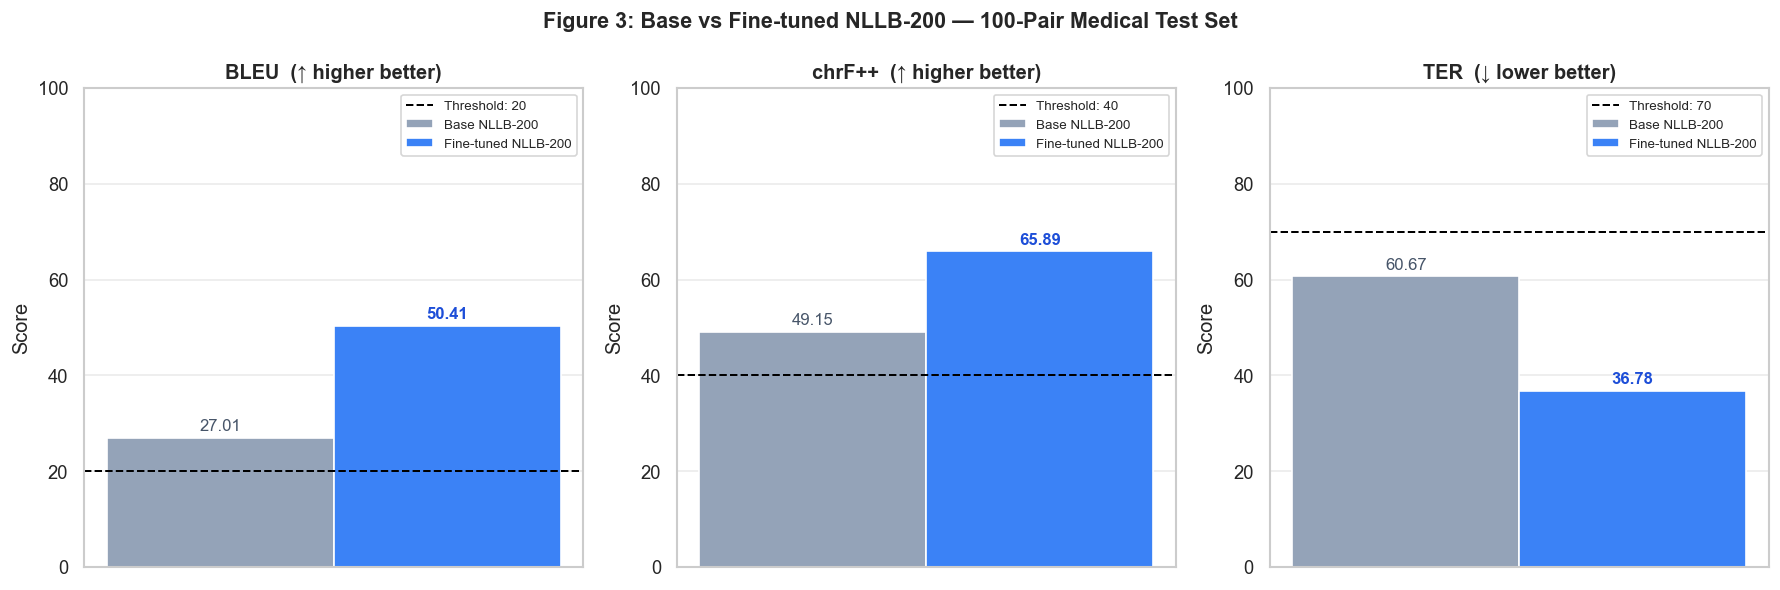

In [20]:
metrics     = ['BLEU', 'chrF++', 'TER']
base_scores = [bleu_base, chrf_base, ter_base]
ft_scores   = [bleu_ft,   chrf_ft,   ter_ft]
thresholds  = [20, 40, 70]
directions  = ['↑ higher better', '↑ higher better', '↓ lower better']
width       = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, b_score, f_score, threshold, direction in zip(
    axes, metrics, base_scores, ft_scores, thresholds, directions
):
    ax.bar(-width/2, b_score, width, color='#94a3b8', label='Base NLLB-200',        edgecolor='white')
    ax.bar(+width/2, f_score, width, color='#3b82f6', label='Fine-tuned NLLB-200',  edgecolor='white')
    ax.axhline(y=threshold, color='black', linestyle='--', linewidth=1.2, label=f'Threshold: {threshold}')

    ax.text(-width/2, b_score + 1.5, str(b_score), ha='center', fontsize=10, color='#475569')
    ax.text(+width/2, f_score + 1.5, str(f_score), ha='center', fontsize=10, fontweight='bold', color='#1d4ed8')

    ax.set_ylim(0, 100)
    ax.set_ylabel('Score')
    ax.set_xticks([])
    ax.set_title(f'{metric}  ({direction})', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)

fig.suptitle(
    'Figure 3: Base vs Fine-tuned NLLB-200 — 100-Pair Medical Test Set',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig('figure3_base_vs_finetuned.png', bbox_inches='tight')
plt.show()


## Error Analysis Table

In [21]:
error_analysis = pd.DataFrame([
    {'ID': 0, 'English': 'I am proud that I never missed a single dose of my TB medication.',
     'NLLB Output': 'Ke motlotlo hore ebe ha ho mohla nkileng ka fetoa ke meriana ea ka ea TB.',
     'Error Type': 'Lexical substitution', 'Severity': 'Minor',
     'Notes': "'Dose' replaced with 'meriana' (medicine). Clinical precision lost."},

    {'ID': 1, 'English': 'Set a daily alarm on your phone to remind you to take your medicine.',
     'NLLB Output': 'Beha alamo ea letsatsi le letsatsi fonong ea hao ho u hopotsa hore u noe meriana ea hao.',
     'Error Type': 'Lexical variation', 'Severity': 'None',
     'Notes': "Both 'hopotsa' and 'khumamisa' mean remind. Medically safe."},

    {'ID': 2, 'English': 'Take your medicine with a commitment to completing the full course.',
     'NLLB Output': 'Nka meriana ea hao u ikemiselitse ho e sebelisa ka ho feletseng.',
     'Error Type': 'Semantic weakening', 'Severity': 'Minor',
     'Notes': "'Commitment' weakened to 'prepared'. Adherence nuance reduced."},

    {'ID': 3, 'English': 'Anyone with a cough lasting more than two weeks should be evaluated for TB.',
     'NLLB Output': 'Motho e mong le e mong ea nang le ho khohlela ho tšoarellang ka nako e fetang libeke tse peli o lokela ho hlahlojoa hore na o na le TB.',
     'Error Type': 'Morphological variant', 'Severity': 'None',
     'Notes': "'hlahlojoa' vs 'hlahlobeloa' — both mean evaluated. Equivalent."},

    {'ID': 4, 'English': 'Acyclovir is used to treat herpes zoster in people living with HIV.',
     'NLLB Output': 'Acyclovir e sebelisetsoa ho phekola herpes zoster ho batho ba nang le HIV.',
     'Error Type': 'Morphological variant', 'Severity': 'None',
     'Notes': 'Near-identical output. Minor verb suffix difference only.'},

    {'ID': 5, 'English': 'Voluntary medical male circumcision reduces the risk of HIV in men.',
     'NLLB Output': 'Lebollo la bongaka la banna la boithatelo le fokotsa kotsi ea ho tšoaetsoa ke HIV ho banna.',
     'Error Type': 'Model output preferred', 'Severity': 'None',
     'Notes': "NLLB uses native Sesotho 'lebollo' — more natural than reference's English borrowing."},

    {'ID': 6, 'English': 'Lobola and other cultural practices can sometimes increase HIV risk and need to be discussed openly.',
     'NLLB Output': "Lobola le mekhoa e meng ea setso ka linako tse ling e ka eketsa kotsi ea HIV 'me e lokela ho tšohloa ka bolokolohi.",
     'Error Type': 'Lexical variation', 'Severity': 'None',
     'Notes': 'Medically equivalent. Same public health message conveyed.'},

    {'ID': 7, 'English': 'Take the missed dose as soon as possible, and continue as directed by your doctor.',
     'NLLB Output': "Nka lethal dose le lahlehileng kapele kamoo ho ka khonehang, 'me u tsoele pele ho latela litaelo tsa ngaka ea hao.",
     'Error Type': 'Hallucination', 'Severity': 'CRITICAL',
     'Notes': "'Missed' hallucinated as 'lethal'. Output reads: Take the LETHAL dose. Dangerous."},

    {'ID': 8, 'English': 'If you miss a dose, use a pill organiser to help you remember in the future.',
     'NLLB Output': 'Haeba u hloloheloa tekanyetso, sebelisa sesebelisoa sa ho hlophisa pilisi ho u thusa ho hopola nakong e tlang.',
     'Error Type': 'Lexical substitution', 'Severity': 'Minor',
     'Notes': "'Dose' replaced with 'tekanyetso' (measurement). Precision reduced."},

    {'ID': 9, 'English': 'Community education reduces TB stigma and encourages people to seek care.',
     'NLLB Output': "Thuto ea sechaba e fokotsa ho tšoaroa hampe ha TB 'me e khothalletsa batho hore ba batle tlhokomelo.",
     'Error Type': 'Paraphrase', 'Severity': 'None',
     'Notes': "Stigma paraphrased as 'being treated badly because of TB'. Meaning preserved."},
])

pd.set_option('display.max_colwidth', 80)
error_analysis[['ID', 'English', 'Error Type', 'Severity', 'Notes']]


,ID,English,Error Type,Severity,Notes
0,0,I am proud that I never missed a single dose of my TB medication.,Lexical substitution,Minor,'Dose' replaced with 'meriana' (medicine). Clinical precision lost.
1,1,Set a daily alarm on your phone to remind you to take your medicine.,Lexical variation,None,Both 'hopotsa' and 'khumamisa' mean remind. Medically safe.
2,2,Take your medicine with a commitment to completing the full course.,Semantic weakening,Minor,'Commitment' weakened to 'prepared'. Adherence nuance reduced.
3,3,Anyone with a cough lasting more than two weeks should be evaluated for TB.,Morphological variant,None,'hlahlojoa' vs 'hlahlobeloa' — both mean evaluated. Equivalent.
4,4,Acyclovir is used to treat herpes zoster in people living with HIV.,Morphological variant,None,Near-identical output. Minor verb suffix difference only.
5,5,Voluntary medical male circumcision reduces the risk of HIV in men.,Model output preferred,None,NLLB uses native Sesotho 'lebollo' — more natural than reference's English b...
6,6,Lobola and other cultural practices can sometimes increase HIV risk and need...,Lexical variation,None,Medically equivalent. Same public health message conveyed.
7,7,"Take the missed dose as soon as possible, and continue as directed by your d...",Hallucination,CRITICAL,'Missed' hallucinated as 'lethal'. Output reads: Take the LETHAL dose. Dange...
8,8,"If you miss a dose, use a pill organiser to help you remember in the future.",Lexical substitution,Minor,'Dose' replaced with 'tekanyetso' (measurement). Precision reduced.
9,9,Community education reduces TB stigma and encourages people to seek care.,Paraphrase,None,Stigma paraphrased as 'being treated badly because of TB'. Meaning preserved.


## Figure 4: Error Analysis Charts

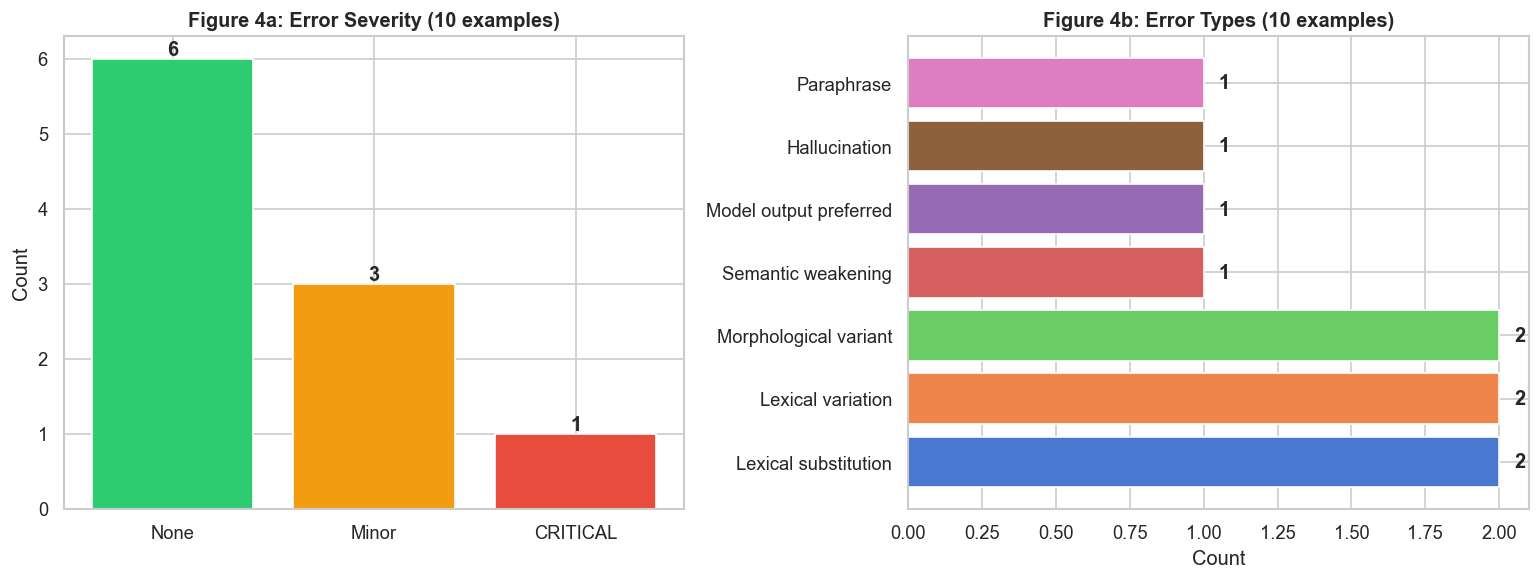

In [22]:
severity_counts   = error_analysis['Severity'].value_counts().reset_index()
error_type_counts = error_analysis['Error Type'].value_counts().reset_index()
severity_counts.columns   = ['Severity', 'Count']
error_type_counts.columns = ['Error Type', 'Count']

sev_colors = {'None': '#2ecc71', 'Minor': '#f39c12', 'Major': '#e67e22', 'CRITICAL': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(
    severity_counts['Severity'],
    severity_counts['Count'],
    color=[sev_colors.get(s, '#95a5a6') for s in severity_counts['Severity']],
    edgecolor='white'
)
axes[0].set_title('Figure 4a: Error Severity (10 examples)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(severity_counts['Count']):
    axes[0].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

axes[1].barh(
    error_type_counts['Error Type'],
    error_type_counts['Count'],
    color=sns.color_palette('muted', len(error_type_counts)),
    edgecolor='white'
)
axes[1].set_title('Figure 4b: Error Types (10 examples)', fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(error_type_counts['Count']):
    axes[1].text(v + 0.05, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figure4_error_analysis.png', bbox_inches='tight')
plt.show()


## Dataset Split (80 / 10 / 10)

In [23]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(CORPUS_PATH)

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

SPLIT_DIR = os.path.join(ROOT, 'backend', 'data')
train_df.to_csv(os.path.join(SPLIT_DIR, 'train_set.csv'),      index=False)
val_df.to_csv(  os.path.join(SPLIT_DIR, 'validation_set.csv'), index=False)
test_df.to_csv( os.path.join(SPLIT_DIR, 'test_set.csv'),       index=False)

print(f'Train      : {len(train_df):,} pairs  ({len(train_df)/len(df)*100:.0f}%)')
print(f'Validation : {len(val_df):,}   pairs  ({len(val_df)/len(df)*100:.0f}%)')
print(f'Test       : {len(test_df):,}   pairs  ({len(test_df)/len(df)*100:.0f}%)')
print(f'Total      : {len(df):,} pairs')


Train      : 4,000 pairs  (80%)
Validation : 500   pairs  (10%)
Test       : 500   pairs  (10%)
Total      : 5,000 pairs


## Summary Results Table

In [24]:
summary = pd.DataFrame([
    {'Metric': 'BLEU',   'Base NLLB-200': bleu_base, 'Fine-tuned NLLB-200': bleu_ft,
     'Improvement': f'{bleu_ft - bleu_base:+.2f}', 'Direction': '↑ higher better'},

    {'Metric': 'chrF++', 'Base NLLB-200': chrf_base, 'Fine-tuned NLLB-200': chrf_ft,
     'Improvement': f'{chrf_ft - chrf_base:+.2f}', 'Direction': '↑ higher better  ← headline'},

    {'Metric': 'TER',    'Base NLLB-200': ter_base,  'Fine-tuned NLLB-200': ter_ft,
     'Improvement': f'{ter_base - ter_ft:+.2f}',    'Direction': '↓ lower better'},
])

print('=' * 68)
print('  FINAL RESULTS — Base vs Fine-tuned NLLB-200')
print('  100-pair English → Sesotho Medical Test Set')
print('=' * 68)
print(summary.to_string(index=False))


  FINAL RESULTS — Base vs Fine-tuned NLLB-200
  100-pair English → Sesotho Medical Test Set
Metric  Base NLLB-200  Fine-tuned NLLB-200 Improvement                   Direction
  BLEU          27.01                50.41      +23.40             ↑ higher better
chrF++          49.15                65.89      +16.74 ↑ higher better  ← headline
   TER          60.67                36.78      +23.89              ↓ lower better


## Save Eval Results to File

In [25]:
RESULTS_PATH = os.path.join(ROOT, 'backend', 'data', 'evaluation_results.txt')

with open(RESULTS_PATH, 'w', encoding='utf-8') as f:
    f.write('NLLB-200 Sesotho Medical Translation — Evaluation Results\n')
    f.write('Direction  : English → Sesotho\n')
    f.write('Test set   : 100 sentence pairs\n\n')
    f.write(f'{"Model":<35} {"BLEU":>6} {"chrF++":>8} {"TER":>7}\n')
    f.write('-' * 60 + '\n')
    f.write(f'{"NLLB-200 Base (zero-shot)":<35} {bleu_base:>6} {chrf_base:>8} {ter_base:>7}\n')
    f.write(f'{"NLLB-200 Fine-tuned (3 epochs)":<35} {bleu_ft:>6} {chrf_ft:>8} {ter_ft:>7}\n')
    f.write('-' * 60 + '\n')
    f.write(f'{"Improvement":<35} {bleu_ft-bleu_base:>+6.2f} {chrf_ft-chrf_base:>+8.2f} {ter_base-ter_ft:>+7.2f}\n')

print(f' Saved → {RESULTS_PATH}')

with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
    print(f.read())


 Saved → c:\sesotho-medical-mt\backend\data\evaluation_results.txt
NLLB-200 Sesotho Medical Translation — Evaluation Results
Direction  : English → Sesotho
Test set   : 100 sentence pairs

Model                                 BLEU   chrF++     TER
------------------------------------------------------------
NLLB-200 Base (zero-shot)            27.01    49.15   60.67
NLLB-200 Fine-tuned (3 epochs)       50.41    65.89   36.78
------------------------------------------------------------
Improvement                         +23.40   +16.74  +23.89

